# Fine-tune Depth Anything V2 (vitb) on GAMUS

**Goal:** domain-adapt DA V2 -- trained on ground-level natural photos -- to nadir aerial imagery, using [GAMUS](https://github.com/EarthNets/RSI-MMSegmentation) (`D:\Datasets\GAMUS`): RGB chips paired with per-pixel AGL (height-above-ground, meters) maps from DC + NYC.

**This is the small validation run** requested before committing to a full training run: a subset of GAMUS, a couple epochs, just enough to confirm the pipeline (data loading -> forward pass -> loss -> backward -> VRAM headroom -> checkpoint) actually works on the RTX 5060 (8GB) before scaling up.

The model keeps predicting a *relative* field (DA V2's own convention: larger = closer to camera), which for a downward-looking sensor is monotonically consistent with AGL height (taller = closer). We fine-tune with a **scale-and-shift-invariant loss** ([ssi_loss.py](ssi_loss.py)) rather than forcing metric units directly -- this matches how `backend/app/depth/da_v2_adapter.py` and the downstream SRTM/GCP calibration step already treat DA V2's output, so a fine-tuned checkpoint drops straight into the existing pipeline via `DEPTH_ANYTHING_V2_CHECKPOINT` in `.env`.

Run this with the **DepthWizard (.venv)** kernel (`backend/.venv`, already has torch+cuda130, h5py, depth_anything_v2 installed).

## 1. Config

Everything you'd tweak for a bigger run lives here. For the first pass, keep `TRAIN_SAMPLES`/`VAL_SAMPLES`/`EPOCHS` small.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path(r"D:\Projects\AkashDristi")
GAMUS_ROOT = Path(r"D:\Datasets\GAMUS")
sys.path.insert(0, str(REPO_ROOT / "training"))

# --- pretrained weights we start from (already downloaded/verified working) ---
BASE_CHECKPOINT = REPO_ROOT / "model" / "depth_anything_v2_vitb.pth"
ENCODER = "vitb"

# --- small validation-run knobs ---
INPUT_SIZE = 350          # multiple of 14 (ViT patch size); GAMUS chips are 1024x1024, resized down
TRAIN_SAMPLES = 400       # subset of the 5,004 train pairs
VAL_SAMPLES = 80          # subset of the 859 val pairs
BATCH_SIZE = 4
EPOCHS = 3
LR_BACKBONE = 1e-6
LR_HEAD = 1e-5
NUM_WORKERS = 2

OUT_CHECKPOINT = REPO_ROOT / "model" / "depth_anything_v2_vitb_gamus_smoke.pth"

print("Base checkpoint exists:", BASE_CHECKPOINT.exists())
print("GAMUS root exists:", GAMUS_ROOT.exists())

Base checkpoint exists: True
GAMUS root exists: True


## 2. Data

`GamusDataset` (see [gamus_dataset.py](gamus_dataset.py)) pairs RGB chips with AGL height maps -- note GAMUS mixes two source cities with different image-file suffixes (`_RGB.h5` for DC, `_IMG.h5` for NYC; heights are always `_AGL.h5`), which the pairing logic handles.

In [2]:
import torch
from torch.utils.data import DataLoader
from gamus_dataset import GamusDataset

train_ds = GamusDataset(GAMUS_ROOT, "train", input_size=INPUT_SIZE, max_samples=TRAIN_SAMPLES, seed=0)
val_ds = GamusDataset(GAMUS_ROOT, "val", input_size=INPUT_SIZE, max_samples=VAL_SAMPLES, seed=0)
print(f"train pairs: {len(train_ds)}  val pairs: {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

train pairs: 400  val pairs: 80


### Sanity-check one sample before spending any GPU time on it

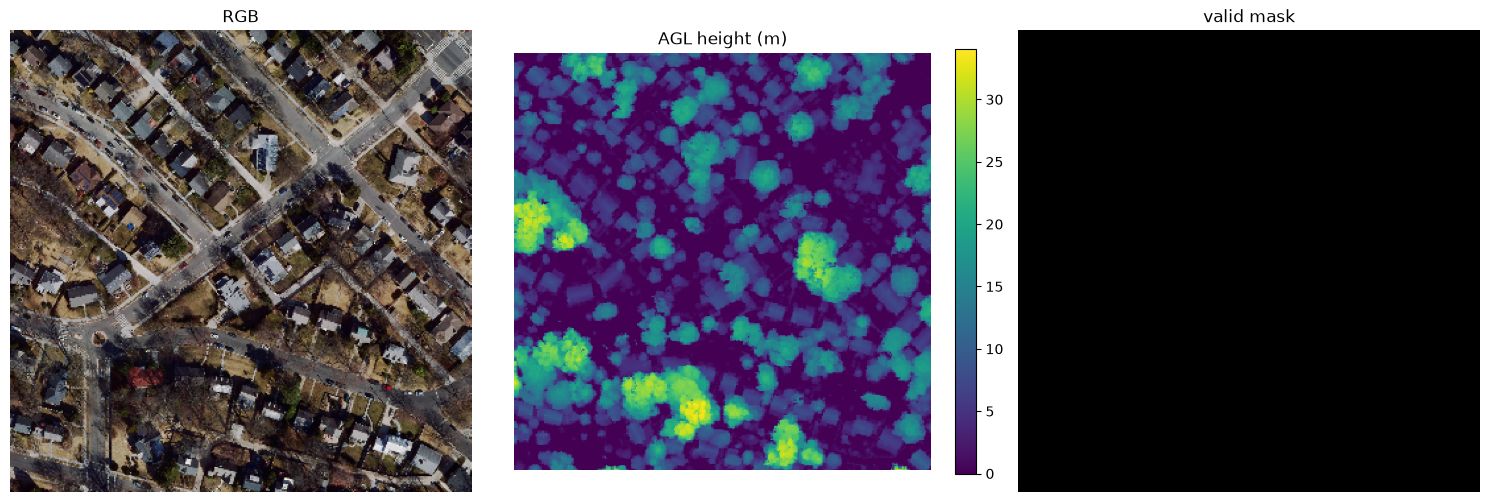

height range in this tile: 0.00m - 34.05m, valid px: 100.0%


In [3]:
import matplotlib.pyplot as plt
import numpy as np

img, height, mask = train_ds[0]

# undo ImageNet normalization for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_disp = (img.permute(1, 2, 0).numpy() * std + mean).clip(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_disp); axes[0].set_title("RGB"); axes[0].axis("off")
im = axes[1].imshow(height.numpy(), cmap="viridis"); axes[1].set_title("AGL height (m)"); axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(mask.numpy(), cmap="gray"); axes[2].set_title("valid mask"); axes[2].axis("off")
plt.tight_layout(); plt.show()

print(f"height range in this tile: {height.min():.2f}m - {height.max():.2f}m, valid px: {mask.float().mean()*100:.1f}%")

## 3. Model

Loads the same pretrained DA V2 vitb checkpoint the backend serves, via the vendored `depth_anything_v2` package (installed editable from `model/Depth-Anything-V2`, same as `app/depth/da_v2_adapter.py`).

In [4]:
from depth_anything_v2.dpt import DepthAnythingV2

MODEL_CONFIGS = {
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

model = DepthAnythingV2(**MODEL_CONFIGS[ENCODER])
state_dict = torch.load(BASE_CHECKPOINT, map_location="cpu")
model.load_state_dict(state_dict)
model = model.to(DEVICE)

def report_vram(label: str) -> None:
    if DEVICE.type != "cuda":
        return
    print(f"[{label}] allocated={torch.cuda.memory_allocated()/1024**2:.0f}MB reserved={torch.cuda.memory_reserved()/1024**2:.0f}MB")

report_vram("after load")

xFormers not available
xFormers not available


Device: cuda NVIDIA GeForce RTX 5060 Laptop GPU
[after load] allocated=373MB reserved=418MB


## 4. Loss, optimizer, AMP

Scale-and-shift-invariant L1 ([ssi_loss.py](ssi_loss.py)) + a lower LR on the pretrained DINOv2 backbone than on the DPT head (standard practice: don't wreck the pretrained features, let the task-specific head adapt faster). Mixed precision + gradient clipping per `CLAUDE.md`'s VRAM discipline.

In [5]:
from ssi_loss import scale_shift_invariant_l1, aligned_metrics

backbone_params = list(model.pretrained.parameters())
head_params = list(model.depth_head.parameters())

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": head_params, "lr": LR_HEAD},
])

scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

## 5. Train

Watch the printed VRAM line on the first batch -- if it's anywhere near 8GB, drop `BATCH_SIZE` or `INPUT_SIZE` in the config cell and restart before going further.

In [ ]:
from tqdm.auto import tqdm

history = {"train_loss": [], "val_rmse": [], "val_mae": [], "val_corr": []}

def run_validation():
    model.eval()
    agg = {"rmse_m": [], "mae_m": [], "correlation": []}
    with torch.no_grad():
        for img, height, mask in val_loader:
            img, height, mask = img.to(DEVICE), height.to(DEVICE), mask.to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
                pred = model(img)
            m = aligned_metrics(pred.float(), height, mask)
            for k in agg:
                agg[k].append(m[k])
    return {k: float(np.mean(v)) for k, v in agg.items()}

print("Pre-fine-tuning baseline on val subset:")
baseline = run_validation()
print(baseline)

for epoch in range(EPOCHS):
    model.train()
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{EPOCHS}")
    for step, (img, height, mask) in enumerate(pbar):
        img, height, mask = img.to(DEVICE), height.to(DEVICE), mask.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
            pred = model(img)
            loss = scale_shift_invariant_l1(pred.float(), height, mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        if epoch == 0 and step == 0:
            report_vram("after first training step")

    val_metrics = run_validation()
    history["train_loss"].append(float(np.mean(epoch_losses)))
    history["val_rmse"].append(val_metrics["rmse_m"])
    history["val_mae"].append(val_metrics["mae_m"])
    history["val_corr"].append(val_metrics["correlation"])
    print(f"epoch {epoch+1}: train_loss={history['train_loss'][-1]:.4f}  "
          f"val_rmse={val_metrics['rmse_m']:.3f}m  val_mae={val_metrics['mae_m']:.3f}m  val_corr={val_metrics['correlation']:.3f}")

report_vram("end of training")

Pre-fine-tuning baseline on val subset:
{'rmse_m': 4.019069474935532, 'mae_m': 2.96860266327858, 'correlation': 0.5398077856587634}


epoch 1/3:   0%|          | 0/100 [00:00<?, ?it/s]

[after first training step] allocated=823MB reserved=3546MB
epoch 1: train_loss=2.8937  val_rmse=3.140m  val_mae=2.048m  val_corr=0.744


epoch 2/3:   0%|          | 0/100 [00:00<?, ?it/s]

epoch 2: train_loss=2.4506  val_rmse=3.022m  val_mae=1.931m  val_corr=0.761


epoch 3/3:   0%|          | 0/100 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001A4FFF24AE0>
Traceback (most recent call last):
  File "d:\Projects\AkashDristi\backend\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "d:\Projects\AkashDristi\backend\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1656, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "D:\Programs\Python3.11\Lib\multiprocessing\process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Programs\Python3.11\Lib\multiprocessing\popen_spawn_win32.py", line 112, in wait
    res = _winapi.WaitForSingleObject(int(self._handle), msecs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt: 


## 6. Did it actually learn anything?

Compare against the pre-fine-tuning baseline computed above. RMSE/MAE are in meters *after* the same per-image scale-shift alignment the loss uses -- this isolates "did the model learn better aerial structure" from "is the absolute scale off" (that's what SRTM/GCP calibration handles downstream in the real pipeline, per `CLAUDE.md` Section 6-7).

baseline (pretrained, no fine-tuning): {'rmse_m': 4.019069474935532, 'mae_m': 2.96860266327858, 'correlation': 0.5398077856587634}
after fine-tuning:                     {'rmse_m': 2.95488201379776, 'mae_m': 1.8805847376585008, 'correlation': 0.7724683117265052}


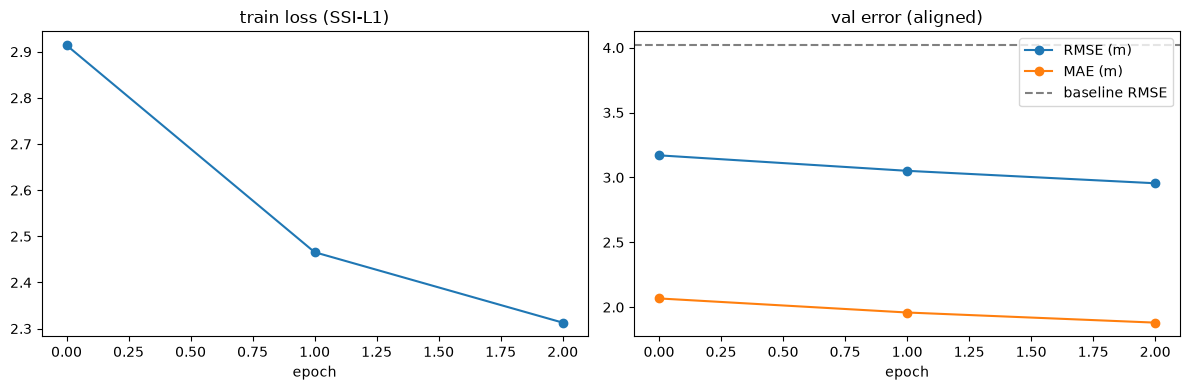

In [8]:
print("baseline (pretrained, no fine-tuning):", baseline)
print("after fine-tuning:                    ",
      {"rmse_m": history["val_rmse"][-1], "mae_m": history["val_mae"][-1], "correlation": history["val_corr"][-1]})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], marker="o"); axes[0].set_title("train loss (SSI-L1)"); axes[0].set_xlabel("epoch")
axes[1].plot(history["val_rmse"], marker="o", label="RMSE (m)")
axes[1].plot(history["val_mae"], marker="o", label="MAE (m)")
axes[1].axhline(baseline["rmse_m"], color="gray", linestyle="--", label="baseline RMSE")
axes[1].set_title("val error (aligned)"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

### Visual check: predictions vs ground truth on a few val tiles

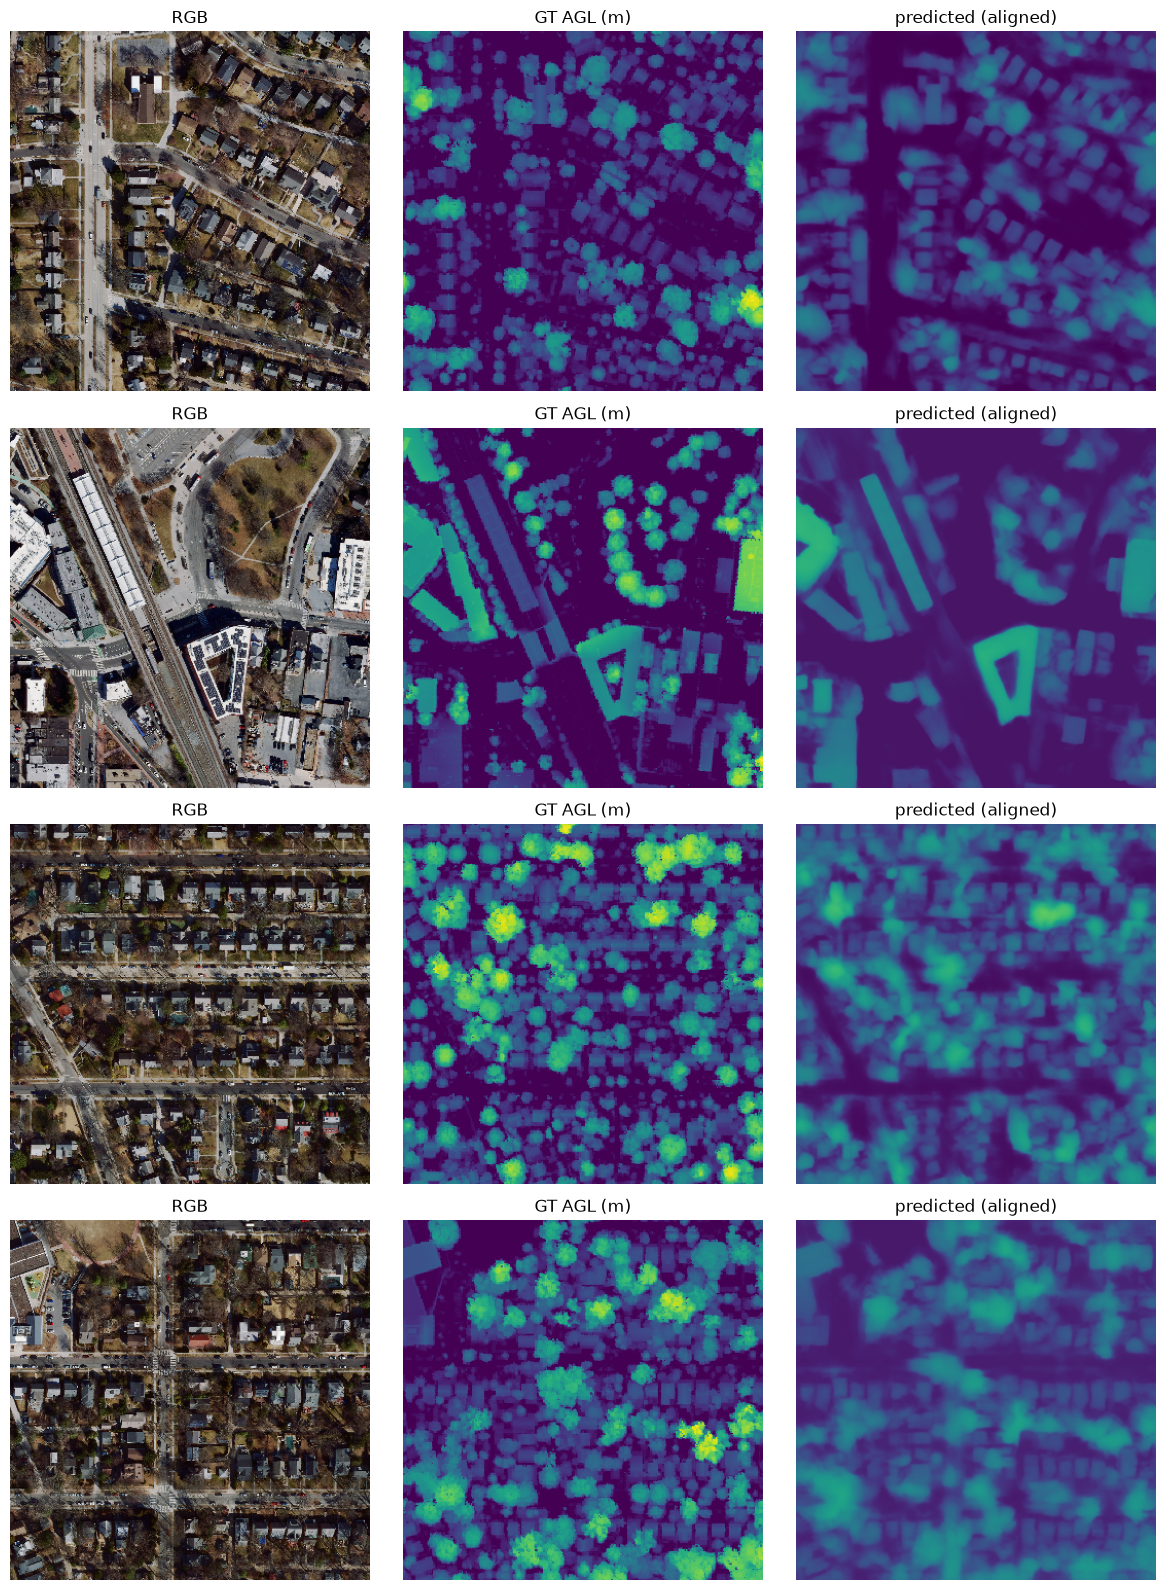

In [9]:
from ssi_loss import compute_scale_and_shift

model.eval()
n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
with torch.no_grad():
    for i in range(n_show):
        img, height, mask = val_ds[i]
        img_b, height_b, mask_b = img.unsqueeze(0).to(DEVICE), height.unsqueeze(0).to(DEVICE), mask.unsqueeze(0).to(DEVICE)
        pred = model(img_b).float()
        a, b = compute_scale_and_shift(pred, height_b, mask_b)
        aligned = (a.view(-1, 1, 1) * pred + b.view(-1, 1, 1))[0].cpu().numpy()

        img_disp = (img.permute(1, 2, 0).numpy() * std + mean).clip(0, 1)
        axes[i, 0].imshow(img_disp); axes[i, 0].set_title("RGB"); axes[i, 0].axis("off")
        vmax = height.max().item()
        axes[i, 1].imshow(height.numpy(), cmap="viridis", vmin=0, vmax=vmax); axes[i, 1].set_title("GT AGL (m)"); axes[i, 1].axis("off")
        axes[i, 2].imshow(aligned, cmap="viridis", vmin=0, vmax=vmax); axes[i, 2].set_title("predicted (aligned)"); axes[i, 2].axis("off")
plt.tight_layout(); plt.show()

## 7. Save the checkpoint

State-dict-only, same format `app/depth/da_v2_adapter.py` loads with `model.load_state_dict(torch.load(...))` -- so this drops straight into the backend by pointing `DEPTH_ANYTHING_V2_CHECKPOINT` in `.env` at it. This is a *smoke-test* checkpoint from a small subset; treat the metrics above as "does the pipeline work", not as a final model.

In [10]:
torch.save(model.state_dict(), OUT_CHECKPOINT)
print("Saved:", OUT_CHECKPOINT, OUT_CHECKPOINT.stat().st_size / 1024**2, "MB")

import gc
del model
gc.collect()
torch.cuda.empty_cache()
report_vram("after cleanup")

Saved: D:\Projects\AkashDristi\model\depth_anything_v2_vitb_gamus_smoke.pth 371.9187545776367 MB
[after cleanup] allocated=1568MB reserved=2062MB


## Next steps (once this looks sane)

- Bump `TRAIN_SAMPLES` toward the full 5,004 (and `VAL_SAMPLES` toward 859), raise `EPOCHS`, and expect a multi-hour run -- worth kicking off as a plain `.py` script in the background rather than a live notebook at that scale.
- Try `INPUT_SIZE=518` (DA V2's native training resolution) once you've confirmed VRAM headroom with the smoke run's batch size.
- If GPU memory is tight at larger scale, freeze `model.pretrained` entirely (`for p in model.pretrained.parameters(): p.requires_grad = False`) and fine-tune only `model.depth_head` -- much less VRAM, still adapts the model to aerial structure via the decoder.
- Point `backend/.env`'s `DEPTH_ANYTHING_V2_CHECKPOINT` at the saved checkpoint and re-run the full DepthWizard pipeline end-to-end on a real aerial image to see the effect in context (DSM, mesh, etc.), not just on isolated val tiles.